# Final CRC Microbiome ML Analysis

This notebook combines the stricter final-analysis workflow with exploratory figures for the write-up, including effect size, model comparison, ROC/confusion matrix, and feature importance.


In [1]:
# Cell 0 — Imports

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import mannwhitneyu

from sklearn.model_selection import (
    StratifiedKFold,
    RepeatedStratifiedKFold,
    cross_val_score,
    cross_val_predict
)

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)
from sklearn.inspection import permutation_importance

sns.set_context("notebook")

In [2]:
# Cell 1 — Configuration and load data
from pathlib import Path
cohort_name = "Yang cohort (PRJNA763023)"  # Change to "Yu_80" when running the Yu notebook

repo_root = Path.cwd().parent
feature_path = repo_root / "data/features/targeted_feature_matrix_Yang_PRJNA763023.csv"
out_dir = repo_root / "results/Yang_PRJNA763023"

df = pd.read_csv(feature_path)

required_cols = ["sample_id", "run_accession", "label"]
missing_required = [c for c in required_cols if c not in df.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

# Keep only binary classification labels
df = df[df["label"].isin(["healthy", "cancer"])].copy()
df["y"] = df["label"].map({"healthy": 0, "cancer": 1})

print("Loaded:", feature_path)
print("Cohort:", cohort_name)
print("Shape:", df.shape)
print("Labels:")
print(df["label"].value_counts())

df.head()

Loaded: /Users/jackpapciak/Columbia/Computational_Genomics/fuso-biomarker/data/features/targeted_feature_matrix_Yang_PRJNA763023.csv
Cohort: Yang cohort (PRJNA763023)
Shape: (40, 117)
Labels:
label
healthy    20
cancer     20
Name: count, dtype: int64


,sample_id,run_accession,label,age_group,library_name,F_nucleatum_species_abundance,Fusobacterium_genus_abundance,total_bacterial_abundance,number_of_detected_species,Shannon_diversity,...,panel_Vescimonas,panel_Vescimonas_log10,panel_Vescimonas_present,panel_Klebsiella,panel_Klebsiella_log10,panel_Klebsiella_present,panel_Odoribacter,panel_Odoribacter_log10,panel_Odoribacter_present,y
0,M_HO_10,SRR16124178,healthy,old,NaN,0.00000,0.00005,0.7243,2163,2.476342,...,0.00736,-2.133063,1,0.00072,-3.142065,1,0.00092,-3.035740,1,0
1,M_HY_20A,SRR16124197,healthy,young,NaN,0.00000,0.00004,0.8062,2072,3.376806,...,0.00561,-2.250960,1,0.00036,-3.442493,1,0.00508,-2.294051,1,0
2,M_HY_15,SRR16124206,healthy,young,NaN,0.00002,0.01570,0.8213,1138,2.875752,...,0.00054,-3.266803,1,0.00012,-3.917215,1,0.00006,-4.214670,0,0
3,M_HY_10,SRR16124212,healthy,young,NaN,0.00000,0.00007,0.8338,1286,3.383866,...,0.01163,-1.934383,1,0.00015,-3.821023,1,0.01002,-1.999089,1,0
4,M_HY_05,SRR16124217,healthy,young,NaN,0.00000,0.00001,0.9546,324,2.467414,...,0.00012,-3.917215,1,0.00008,-4.091515,0,0.00179,-2.746904,1,0


In [3]:
# Cell 2 — Define feature groups

meta_cols = [
    "sample_id", "run_accession", "label", "y", "age_group", "library_name"
]
meta_cols = [c for c in meta_cols if c in df.columns]

core_feature_cols = [
    "F_nucleatum_species_abundance",
    "Fusobacterium_genus_abundance",
    "total_bacterial_abundance",
    "number_of_detected_species",
    "Shannon_diversity",
    "sequencing_depth_proxy",
]
core_feature_cols = [c for c in core_feature_cols if c in df.columns]

diversity_cols = [
    c for c in [
        "Shannon_diversity",
        "number_of_detected_species",
        "total_bacterial_abundance",
    ]
    if c in df.columns
]

# Raw panel abundance columns are detected but NOT used in modeling
panel_abundance_cols = [
    c for c in df.columns
    if c.startswith("panel_")
    and not c.endswith("_log10")
    and not c.endswith("_present")
]

# Use these for modeling
panel_log_cols = [
    c for c in df.columns
    if c.startswith("panel_") and c.endswith("_log10")
]

panel_present_cols = [
    c for c in df.columns
    if c.startswith("panel_") and c.endswith("_present")
]

# Modeling features exclude raw panel abundance columns
all_feature_cols = list(dict.fromkeys(
    core_feature_cols + panel_log_cols + panel_present_cols
))

for col in all_feature_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("Metadata columns:", meta_cols)
print("Core features:", len(core_feature_cols))
print("Raw panel abundance features detected but excluded:", len(panel_abundance_cols))
print("Panel log features used:", len(panel_log_cols))
print("Panel presence features used:", len(panel_present_cols))
print("Diversity features:", diversity_cols)

Metadata columns: ['sample_id', 'run_accession', 'label', 'y', 'age_group', 'library_name']
Core features: 6
Raw panel abundance features detected but excluded: 35
Panel log features used: 35
Panel presence features used: 35
Diversity features: ['Shannon_diversity', 'number_of_detected_species', 'total_bacterial_abundance']


In [4]:
# Cell 3 — Feature sanity checks

feature_summary = pd.DataFrame({
    "feature": all_feature_cols,
    "missing": [df[c].isna().sum() for c in all_feature_cols],
    "n_unique": [df[c].nunique(dropna=True) for c in all_feature_cols],
    "mean": [df[c].mean() for c in all_feature_cols],
    "std": [df[c].std() for c in all_feature_cols],
})

print("Features with the least variation:")
display(feature_summary.sort_values("n_unique").head(20))

print("Top missing values:")
display(df.isnull().sum().sort_values(ascending=False).head(15))

Features with the least variation:


,feature,missing,n_unique,mean,std
56,panel_Alistipes_present,0,1,1.000,0.000000
42,panel_Bacteroides_fragilis_present,0,1,1.000,0.000000
71,panel_Prevotella_present,0,1,1.000,0.000000
53,panel_Segatella_present,0,1,1.000,0.000000
45,panel_Peptostreptococcus_anaerobius_present,0,1,0.000,0.000000
52,panel_Phocaeicola_present,0,1,1.000,0.000000
51,panel_Bacteroides_present,0,1,1.000,0.000000
55,panel_Parabacteroides_present,0,1,1.000,0.000000
10,panel_Peptostreptococcus_anaerobius_log10,0,1,-6.000,0.000000
54,panel_Faecalibacterium_present,0,2,0.975,0.158114


Top missing values:


library_name                        40
sample_id                            0
panel_Ruminococcus                   0
panel_Lachnospira                    0
panel_Flavonifractor_present         0
panel_Flavonifractor_log10           0
panel_Flavonifractor                 0
panel_Roseburia_present              0
panel_Roseburia_log10                0
panel_Roseburia                      0
panel_Mediterraneibacter_present     0
panel_Mediterraneibacter_log10       0
panel_Mediterraneibacter             0
panel_Ruminococcus_present           0
panel_Ruminococcus_log10             0
dtype: int64

In [5]:
# Cell 4 — Class-level descriptive summaries

summary_cols = [c for c in [
    "sequencing_depth_proxy",
    "number_of_detected_species",
    "Shannon_diversity",
    "total_bacterial_abundance"
] if c in df.columns]

if summary_cols:
    display(df.groupby("label")[summary_cols].describe().T)
else:
    print("No summary columns found.")

label                                   cancer       healthy
sequencing_depth_proxy     count  2.000000e+01  2.000000e+01
                           mean   3.384692e+06  3.588047e+06
                           std    3.530067e+06  3.707929e+06
                           min    0.000000e+00  0.000000e+00
                           25%    0.000000e+00  0.000000e+00
                           50%    2.858129e+06  2.993739e+06
                           75%    6.486480e+06  7.453708e+06
                           max    8.372166e+06  7.857084e+06
number_of_detected_species count  2.000000e+01  2.000000e+01
                           mean   1.731250e+03  1.382000e+03
                           std    1.476295e+03  8.834386e+02
                           min    2.920000e+02  9.400000e+01
                           25%    6.037500e+02  8.475000e+02
                           50%    1.133000e+03  1.129500e+03
                           75%    2.473250e+03  2.014250e+03
                           max    4.805000e+03  3.534000e+03
Shannon_diversity          count  2.000000e+01  2.000000e+01
                           mean   3.069794e+00  2.742244e+00
                           std    9.291091e-01  1.032691e+00
                           min    1.393402e+00  2.761381e-01
                           25%    2.451793e+00  2.081185e+00
                           50%    3.092979e+00  2.839456e+00
                           75%    3.766365e+00  3.434846e+00
                           max    4.466062e+00  4.366077e+00
total_bacterial_abundance  count  2.000000e+01  2.000000e+01
                           mean   7.850600e-01  7.627500e-01
                           std    1.166101e-01  1.993062e-01
                           min    5.809000e-01  6.200000e-02
                           25%    7.028000e-01  7.706750e-01
                           50%    7.934000e-01  8.219500e-01
                           75%    8.698750e-01  8.438250e-01
                           max    9.652000e-01  9.546000e-01

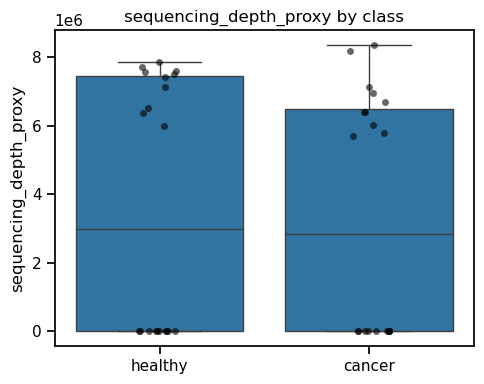

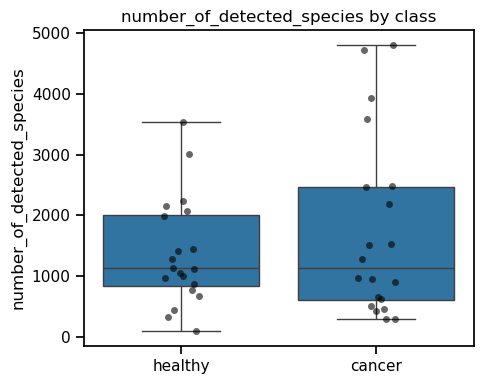

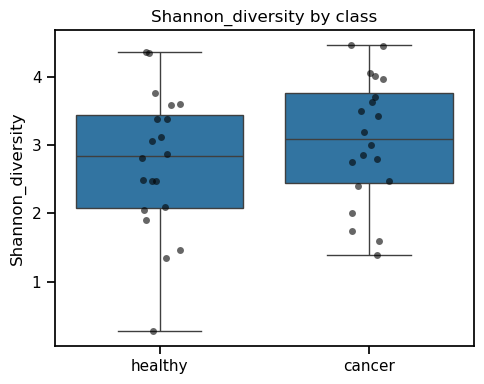

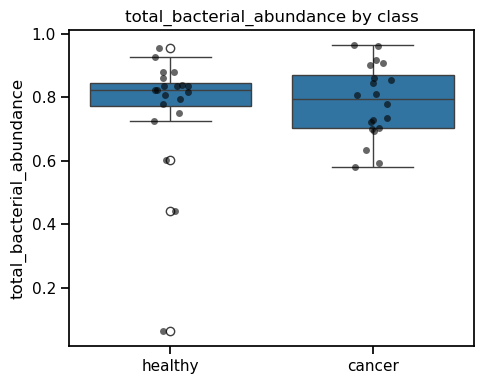

In [6]:
# Cell 5 — Plot core community metrics by class

for col in summary_cols:
    plt.figure(figsize=(5, 4))
    sns.boxplot(data=df, x="label", y=col)
    sns.stripplot(data=df, x="label", y=col, color="black", alpha=0.6)
    plt.title(f"{col} by class")
    plt.xlabel("")
    plt.tight_layout()
    plt.show()

In [7]:
# Cell 6 — Effect size analysis helper

# For presence features, abs_diff is a difference in prevalence.
# For log abundance features, abs_diff is a difference in mean log10 abundance.

def compute_univariate_effects(feature_cols, label="feature"):
    results = []

    for col in feature_cols:
        if col not in df.columns:
            continue

        # Skip only if completely constant across all samples
        if df[col].nunique(dropna=True) <= 1:
            continue

        g0 = df.loc[df["y"] == 0, col]  # healthy
        g1 = df.loc[df["y"] == 1, col]  # cancer

        try:
            stat, p = mannwhitneyu(g0, g1, alternative="two-sided")
        except ValueError:
            stat, p = np.nan, np.nan

        results.append({
            "feature": col,
            "feature_source": label,
            "healthy_mean": g0.mean(),
            "cancer_mean": g1.mean(),
            "mean_diff": g1.mean() - g0.mean(),
            "abs_diff": abs(g1.mean() - g0.mean()),
            "p_value": p,
        })

    out = pd.DataFrame(results)
    if out.empty:
        return out

    return out.sort_values(["abs_diff", "p_value"], ascending=[False, True]).reset_index(drop=True)

In [8]:
# Cell 7 — Effect size: presence features

presence_effects = compute_univariate_effects(panel_present_cols, label="presence")

if presence_effects.empty:
    print("No variable presence features found.")
else:
    display(presence_effects.head(15))

,feature,feature_source,healthy_mean,cancer_mean,mean_diff,abs_diff,p_value
0,panel_Lachnospira_present,presence,0.95,0.70,-0.25,0.25,0.041961
1,panel_Parvimonas_micra_present,presence,0.00,0.20,0.20,0.20,0.039817
2,panel_Collinsella_present,presence,0.60,0.75,0.15,0.15,0.325443
3,panel_Paraprevotella_present,presence,0.90,1.00,0.10,0.10,0.162449
4,panel_Klebsiella_present,presence,0.80,0.90,0.10,0.10,0.393874
5,panel_Phascolarctobacterium_present,presence,0.85,0.75,-0.10,0.10,0.446592
6,panel_Bifidobacterium_longum_present,presence,0.65,0.75,0.10,0.10,0.506466
7,panel_Escherichia_coli_present,presence,0.95,1.00,0.05,0.05,0.342112
8,panel_Faecalibacterium_prausnitzii_present,presence,0.95,1.00,0.05,0.05,0.342112
9,panel_Faecalibacterium_present,presence,0.95,1.00,0.05,0.05,0.342112


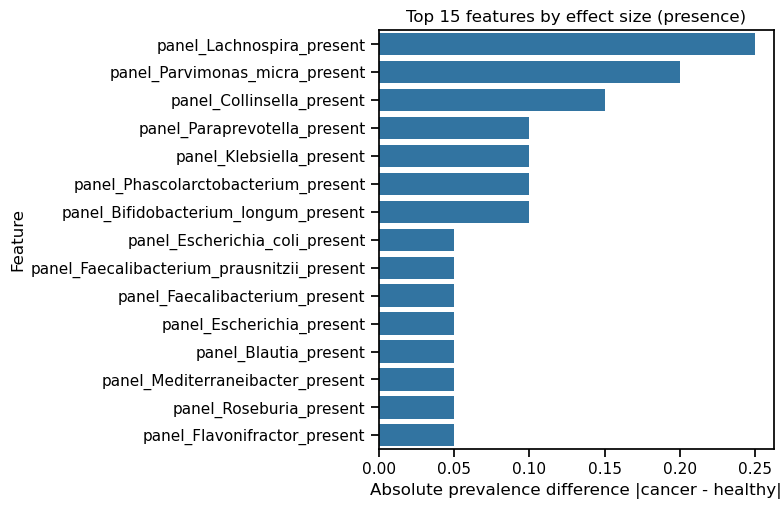

In [9]:
# Cell 8 — Plot effect size for presence features

if not presence_effects.empty:
    top_n = min(15, len(presence_effects))
    plot_df = presence_effects.head(top_n).copy()

    plt.figure(figsize=(8, max(4, 0.35 * top_n)))
    sns.barplot(data=plot_df, x="abs_diff", y="feature", orient="h")
    plt.title(f"Top {top_n} features by effect size (presence)")
    plt.xlabel("Absolute prevalence difference |cancer - healthy|")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()
else:
    print("Skipped: no variable presence features.")

In [10]:
# Cell 9 — Effect size: log10 abundance features

log_effects = compute_univariate_effects(panel_log_cols, label="log10_abundance")

if log_effects.empty:
    print("No variable log10 abundance features found.")
else:
    display(log_effects.head(15))

,feature,feature_source,healthy_mean,cancer_mean,mean_diff,abs_diff,p_value
0,panel_Collinsella_log10,log10_abundance,-3.877084,-3.321849,0.555236,0.555236,0.059894
1,panel_Fusobacterium_nucleatum_log10,log10_abundance,-5.645458,-5.190009,0.455449,0.455449,0.055801
2,panel_Klebsiella_log10,log10_abundance,-3.520108,-3.099711,0.420396,0.420396,0.198729
3,panel_Lachnospira_log10,log10_abundance,-2.793521,-3.202329,-0.408808,0.408808,0.069892
4,panel_Mediterraneibacter_log10,log10_abundance,-2.452878,-2.134328,0.318550,0.318550,0.107495
5,panel_Bifidobacterium_log10,log10_abundance,-3.149283,-2.842793,0.306490,0.306490,0.560852
6,panel_Escherichia_log10,log10_abundance,-2.544808,-2.253892,0.290916,0.290916,0.694877
7,panel_Escherichia_coli_log10,log10_abundance,-2.548975,-2.259991,0.288984,0.288984,0.694891
8,panel_Bifidobacterium_longum_log10,log10_abundance,-3.746354,-3.459674,0.286681,0.286681,0.481703
9,panel_Roseburia_intestinalis_log10,log10_abundance,-2.723753,-2.969276,-0.245522,0.245522,0.140420


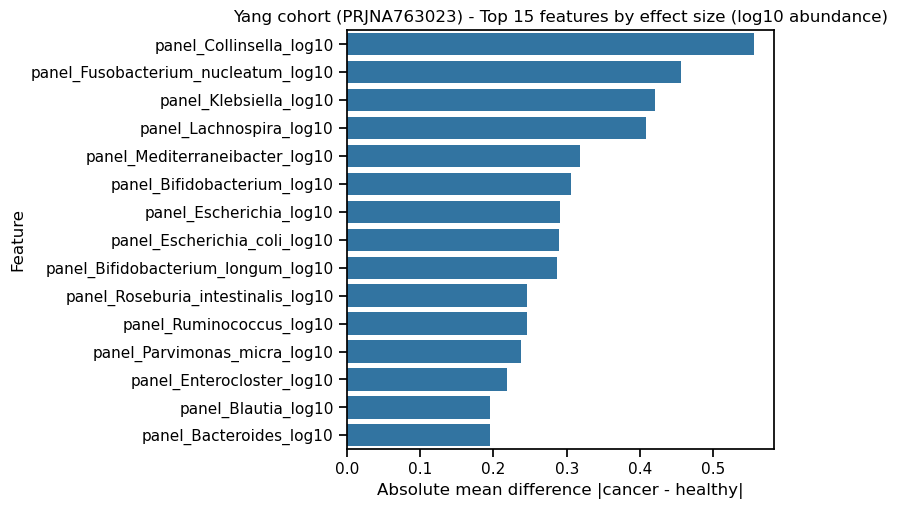

In [11]:
# Cell 10 — Plot effect size for log10 abundance features

if not log_effects.empty:
    top_n = min(15, len(log_effects))
    plot_df = log_effects.head(top_n).copy()

    plt.figure(figsize=(8, max(4, 0.35 * top_n)))
    sns.barplot(data=plot_df, x="abs_diff", y="feature", orient="h")
    plt.title(f"{cohort_name} - Top {top_n} features by effect size (log10 abundance)")
    plt.xlabel("Absolute mean difference |cancer - healthy|")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()
else:
    print("Skipped: no variable log10 abundance features.")

In [12]:
# Cell 11 — Optional: inspect direction of top effect-size features

# Positive mean_diff = higher in cancer
# Negative mean_diff = higher in healthy

if not log_effects.empty:
    display(log_effects.head(20)[[
        "feature", "healthy_mean", "cancer_mean", "mean_diff", "abs_diff", "p_value"
    ]])
elif not presence_effects.empty:
    display(presence_effects.head(20)[[
        "feature", "healthy_mean", "cancer_mean", "mean_diff", "abs_diff", "p_value"
    ]])
else:
    print("No variable panel features available for effect-size table.")

,feature,healthy_mean,cancer_mean,mean_diff,abs_diff,p_value
0,panel_Collinsella_log10,-3.877084,-3.321849,0.555236,0.555236,0.059894
1,panel_Fusobacterium_nucleatum_log10,-5.645458,-5.190009,0.455449,0.455449,0.055801
2,panel_Klebsiella_log10,-3.520108,-3.099711,0.420396,0.420396,0.198729
3,panel_Lachnospira_log10,-2.793521,-3.202329,-0.408808,0.408808,0.069892
4,panel_Mediterraneibacter_log10,-2.452878,-2.134328,0.318550,0.318550,0.107495
5,panel_Bifidobacterium_log10,-3.149283,-2.842793,0.306490,0.306490,0.560852
6,panel_Escherichia_log10,-2.544808,-2.253892,0.290916,0.290916,0.694877
7,panel_Escherichia_coli_log10,-2.548975,-2.259991,0.288984,0.288984,0.694891
8,panel_Bifidobacterium_longum_log10,-3.746354,-3.459674,0.286681,0.286681,0.481703
9,panel_Roseburia_intestinalis_log10,-2.723753,-2.969276,-0.245522,0.245522,0.140420


In [13]:
# Cell 12 — Define biologically fixed feature sets

# These feature sets are fixed by design, not selected from labels inside the notebook.

feature_sets = {
    "fuso_only": [
        c for c in [
            "Fusobacterium_genus_abundance",
            "F_nucleatum_species_abundance",
        ]
        if c in df.columns
    ],

    "diversity_only": diversity_cols,

    "panel_log": panel_log_cols,

    "panel_presence": panel_present_cols,

    "panel_log_plus_diversity": panel_log_cols + diversity_cols,

    "panel_presence_plus_diversity": panel_present_cols + diversity_cols,
}

for name, cols in feature_sets.items():
    print(f"{name}: {len(cols)} features")

fuso_only: 2 features
diversity_only: 3 features
panel_log: 35 features
panel_presence: 35 features
panel_log_plus_diversity: 38 features
panel_presence_plus_diversity: 38 features


In [14]:
# Cell 13 — Define models

models = {
    "logistic_l2": LogisticRegression(
        l1_ratio=0.0,
        solver="liblinear",
        C=1.0,
        max_iter=2000,
        random_state=42
    ),
    
    "logistic_l1": LogisticRegression(
        l1_ratio=1.0,
        solver="liblinear",
        C=2.0,
        max_iter=2000,
        random_state=42
    ),

    "random_forest": RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=1,
        max_features="sqrt",
        random_state=42
    )
}

In [15]:
# Cell 14 — Cross-validation setup

# Main estimate: repeated stratified 5-fold CV.
# Sensitivity checks below compare other CV schemes.

cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=10,
    random_state=42,
)

cv_single = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

In [16]:
# Cell 15 — Pipeline builder

def build_pipeline(model, use_scaler=True):
    steps = [
        ("imputer", SimpleImputer(strategy="constant", fill_value=0))
    ]

    if use_scaler and isinstance(model, LogisticRegression):
        steps.append(("scaler", StandardScaler()))

    steps.append(("model", model))

    return Pipeline(steps)

In [17]:
# Cell 16 — Evaluate all feature sets and models

rows = []

for fs_name, cols in feature_sets.items():
    if len(cols) == 0:
        continue

    X = df[cols]
    y = df["y"]

    for model_name, model in models.items():
        pipe = build_pipeline(model)

        auc_scores = cross_val_score(
            pipe,
            X,
            y,
            cv=cv,
            scoring="roc_auc",
        )

        rows.append({
            "feature_set": fs_name,
            "model": model_name,
            "n_features": len(cols),
            "auc_mean": auc_scores.mean(),
            "auc_std": auc_scores.std(),
            "auc_min": auc_scores.min(),
            "auc_max": auc_scores.max(),
            "auc_2.5%": np.percentile(auc_scores, 2.5),
            "auc_97.5%": np.percentile(auc_scores, 97.5),
        })

results_df = pd.DataFrame(rows).sort_values("auc_mean", ascending=False)
results_df

,feature_set,model,n_features,auc_mean,auc_std,auc_min,auc_max,auc_2.5%,auc_97.5%
10,panel_presence,logistic_l1,35,0.693125,0.166383,0.34375,1.00000,0.350781,0.992969
16,panel_presence_plus_diversity,logistic_l1,38,0.656875,0.195904,0.25000,1.00000,0.250000,0.985937
9,panel_presence,logistic_l2,35,0.638750,0.189897,0.15625,0.93750,0.187500,0.930469
15,panel_presence_plus_diversity,logistic_l2,38,0.616250,0.203873,0.12500,1.00000,0.201563,0.937500
11,panel_presence,random_forest,35,0.608750,0.191136,0.18750,0.93750,0.218750,0.906250
2,fuso_only,random_forest,2,0.608125,0.130685,0.25000,0.90625,0.375000,0.860937
17,panel_presence_plus_diversity,random_forest,38,0.588125,0.197908,0.18750,1.00000,0.225781,0.923437
1,fuso_only,logistic_l1,2,0.584375,0.186272,0.18750,0.96875,0.194531,0.923437
14,panel_log_plus_diversity,random_forest,38,0.574375,0.222897,0.12500,1.00000,0.187500,0.875000
0,fuso_only,logistic_l2,2,0.573125,0.182283,0.18750,1.00000,0.194531,0.947656


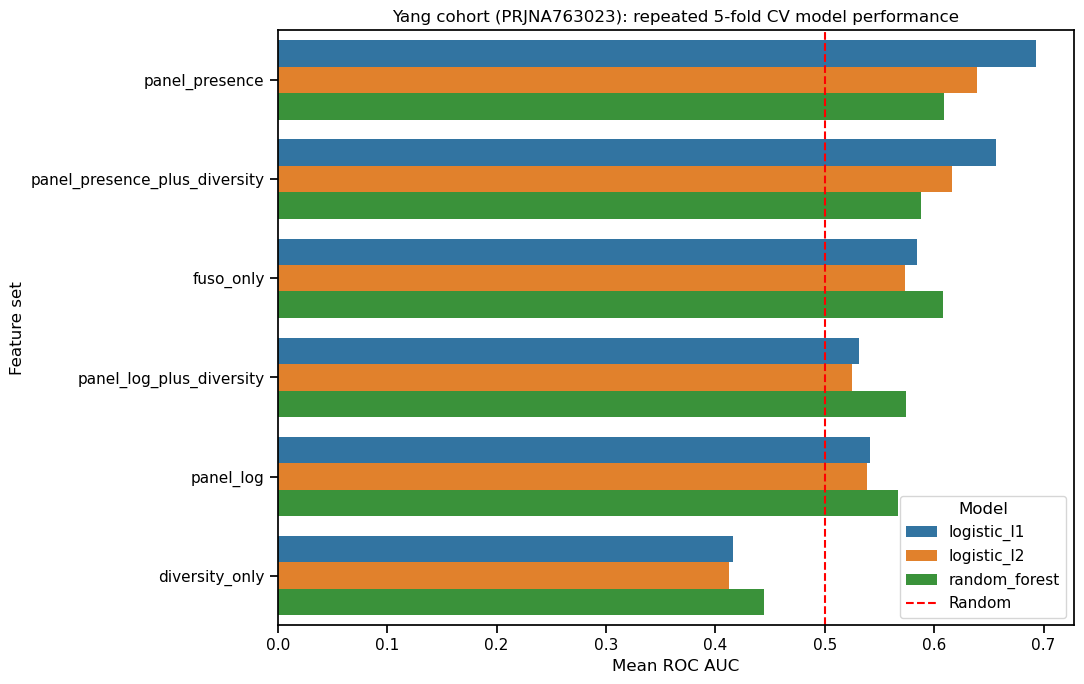

In [18]:
# Cell 17 — Plot model comparison

plot_df = results_df.copy()

feature_order = (
    plot_df.groupby("feature_set")["auc_mean"]
    .max()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(11, 7))

sns.barplot(
    data=plot_df,
    x="auc_mean",
    y="feature_set",
    hue="model",
    order=feature_order,
)

plt.axvline(0.5, linestyle="--", color="red", label="Random")
plt.xlabel("Mean ROC AUC")
plt.ylabel("Feature set")
plt.title(f"{cohort_name}: repeated 5-fold CV model performance")
plt.legend(title="Model")
plt.tight_layout()
plt.show()

,feature_set,model,cv_type,auc_mean,auc_std
0,fuso_only,random_forest,single_5fold,0.637500,0.107529
1,fuso_only,random_forest,repeated_5fold,0.608125,0.130685
2,diversity_only,random_forest,single_5fold,0.462500,0.170477
3,diversity_only,random_forest,repeated_5fold,0.444375,0.170739
4,panel_log,random_forest,single_5fold,0.587500,0.222205
5,panel_log,random_forest,repeated_5fold,0.566875,0.211857
6,panel_presence,logistic_l1,single_5fold,0.743750,0.209538
7,panel_presence,logistic_l1,repeated_5fold,0.693125,0.166383
8,panel_log_plus_diversity,random_forest,single_5fold,0.606250,0.174105
9,panel_log_plus_diversity,random_forest,repeated_5fold,0.574375,0.222897


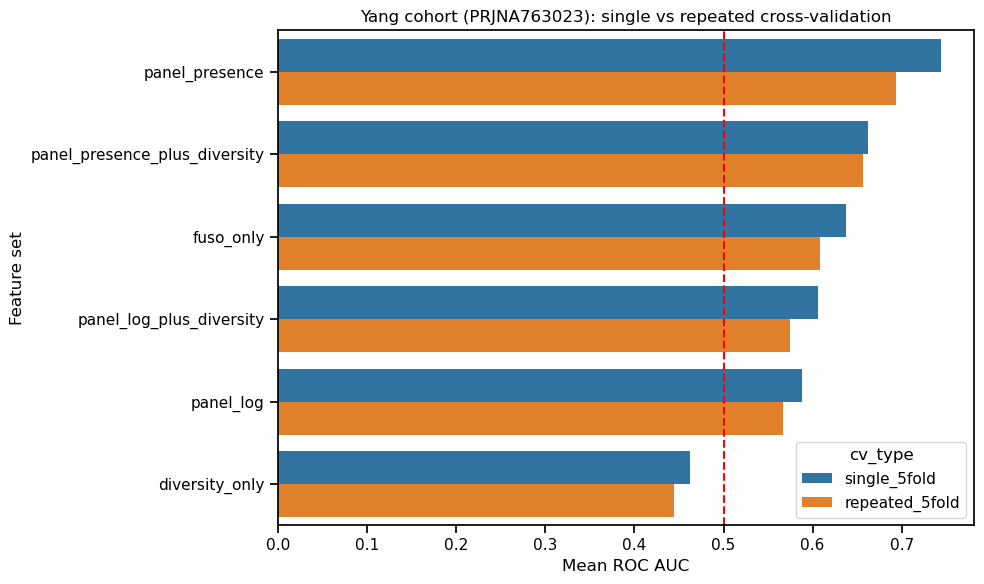

In [19]:
# Cell 18 — Compare single 5-fold vs repeated 5-fold CV

comparison_rows = []

for fs_name, cols in feature_sets.items():
    if len(cols) == 0:
        continue

    X = df[cols]
    y = df["y"]

    # Use the best model from the main repeated-CV table for this feature set
    best_model_for_fs = (
        results_df[results_df["feature_set"] == fs_name]
        .sort_values("auc_mean", ascending=False)
        .iloc[0]["model"]
    )
    model = models[best_model_for_fs]
    pipe = build_pipeline(model)

    single_scores = cross_val_score(pipe, X, y, cv=cv_single, scoring="roc_auc")
    repeated_scores = cross_val_score(pipe, X, y, cv=cv, scoring="roc_auc")

    comparison_rows.append({
        "feature_set": fs_name,
        "model": best_model_for_fs,
        "cv_type": "single_5fold",
        "auc_mean": single_scores.mean(),
        "auc_std": single_scores.std(),
    })

    comparison_rows.append({
        "feature_set": fs_name,
        "model": best_model_for_fs,
        "cv_type": "repeated_5fold",
        "auc_mean": repeated_scores.mean(),
        "auc_std": repeated_scores.std(),
    })

cv_comparison_df = pd.DataFrame(comparison_rows)
display(cv_comparison_df)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=cv_comparison_df,
    x="auc_mean",
    y="feature_set",
    hue="cv_type",
    order=feature_order,
)
plt.axvline(0.5, linestyle="--", color="red")
plt.xlabel("Mean ROC AUC")
plt.ylabel("Feature set")
plt.title(f"{cohort_name}: single vs repeated cross-validation")
plt.tight_layout()
plt.show()

,cv_scheme,feature_set,model,auc_mean,auc_std
9,5fold_x10,panel_presence,logistic_l1,0.693125,0.166383
15,8fold_x10,panel_presence,logistic_l1,0.677083,0.217456
3,3fold_x10,panel_presence,logistic_l1,0.672052,0.124711
17,8fold_x10,panel_presence_plus_diversity,logistic_l1,0.666667,0.255495
11,5fold_x10,panel_presence_plus_diversity,logistic_l1,0.656875,0.195904
0,3fold_x10,fuso_only,logistic_l1,0.628628,0.098579
5,3fold_x10,panel_presence_plus_diversity,logistic_l1,0.625510,0.129759
6,5fold_x10,fuso_only,logistic_l1,0.584375,0.186272
2,3fold_x10,panel_log,logistic_l1,0.563605,0.138376
12,8fold_x10,fuso_only,logistic_l1,0.559375,0.258600


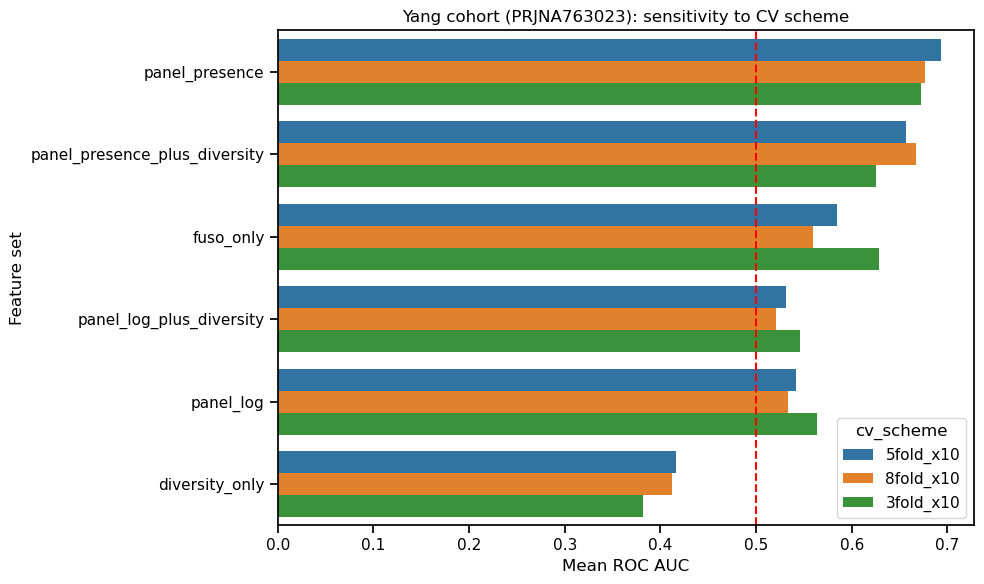

In [20]:
# Cell 19 — Optional sensitivity to CV scheme

cv_options = {
    "3fold_x10": RepeatedStratifiedKFold(n_splits=3, n_repeats=10, random_state=42),
    "5fold_x10": RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42),
    "8fold_x10": RepeatedStratifiedKFold(n_splits=8, n_repeats=10, random_state=42),
}

cv_rows = []

for cv_name, cv_obj in cv_options.items():
    for fs_name, cols in feature_sets.items():
        if len(cols) == 0:
            continue

        X = df[cols]
        y = df["y"]

        # Keep sensitivity plot compact by using logistic_l1 only
        model_name = "logistic_l1"
        model = models[model_name]
        pipe = build_pipeline(model)

        scores = cross_val_score(pipe, X, y, cv=cv_obj, scoring="roc_auc")

        cv_rows.append({
            "cv_scheme": cv_name,
            "feature_set": fs_name,
            "model": model_name,
            "auc_mean": scores.mean(),
            "auc_std": scores.std(),
        })

cv_sensitivity_df = pd.DataFrame(cv_rows).sort_values("auc_mean", ascending=False)
display(cv_sensitivity_df.head(20))

plt.figure(figsize=(10, 6))
sns.barplot(
    data=cv_sensitivity_df,
    x="auc_mean",
    y="feature_set",
    hue="cv_scheme",
    order=feature_order,
)
plt.axvline(0.5, linestyle="--", color="red")
plt.xlabel("Mean ROC AUC")
plt.ylabel("Feature set")
plt.title(f"{cohort_name}: sensitivity to CV scheme")
plt.tight_layout()
plt.show()

In [21]:
# Cell 20 — Choose final model for detailed figures

best_row = results_df.iloc[0]

best_feature_set = best_row["feature_set"]
best_model_name = best_row["model"]
best_features = feature_sets[best_feature_set]
best_model = models[best_model_name]

print("Best feature set:", best_feature_set)
print("Best model:", best_model_name)
print("Number of features:", len(best_features))
print("Repeated CV mean AUC:", best_row["auc_mean"])
print("Repeated CV AUC std:", best_row["auc_std"])

Best feature set: panel_presence
Best model: logistic_l1
Number of features: 35
Repeated CV mean AUC: 0.693125
Repeated CV AUC std: 0.16638270079849046


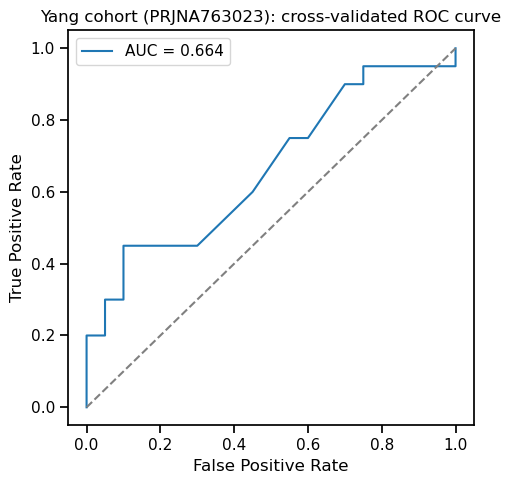

In [22]:
# Cell 21 — Cross-validated ROC curve for final model

X_best = df[best_features]
y = df["y"]
best_pipe = build_pipeline(best_model)

# Use a single 5-fold split for a single ROC visualization.
# The repeated-CV table remains the main performance estimate.
y_proba = cross_val_predict(
    best_pipe,
    X_best,
    y,
    cv=cv_single,
    method="predict_proba",
)[:, 1]

roc_auc = roc_auc_score(y, y_proba)
fpr, tpr, _ = roc_curve(y, y_proba)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"{cohort_name}: cross-validated ROC curve")
plt.legend()
plt.tight_layout()
plt.show()

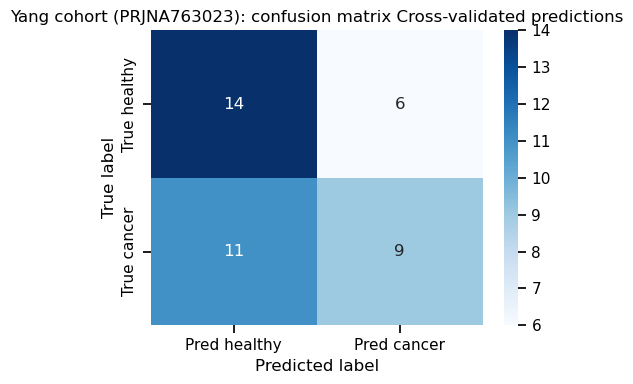

              precision    recall  f1-score   support

     healthy       0.56      0.70      0.62        20
      cancer       0.60      0.45      0.51        20

    accuracy                           0.57        40
   macro avg       0.58      0.57      0.57        40
weighted avg       0.58      0.57      0.57        40



In [23]:
# Cell 22 — Cross-validated confusion matrix for final model

y_pred = (y_proba >= 0.5).astype(int)
cm = confusion_matrix(y, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred healthy", "Pred cancer"],
    yticklabels=["True healthy", "True cancer"],
)
plt.title(f"{cohort_name}: confusion matrix Cross-validated predictions")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

print(classification_report(y, y_pred, target_names=["healthy", "cancer"]))

,feature,coefficient,abs_coefficient,direction
25,panel_Lachnospira_present,-1.806946,1.806946,healthy-associated
31,panel_Collinsella_present,0.959563,0.959563,cancer-associated
3,panel_Parvimonas_micra_present,0.913878,0.913878,cancer-associated
29,panel_Paraprevotella_present,0.425612,0.425612,cancer-associated
21,panel_Ruminococcus_present,-0.275247,0.275247,healthy-associated
16,panel_Escherichia_present,0.235988,0.235988,cancer-associated
5,panel_Faecalibacterium_prausnitzii_present,0.232059,0.232059,cancer-associated
6,panel_Agathobacter_rectalis_present,-0.228888,0.228888,healthy-associated
23,panel_Roseburia_present,0.214239,0.214239,cancer-associated
13,panel_Faecalibacterium_present,0.170281,0.170281,cancer-associated


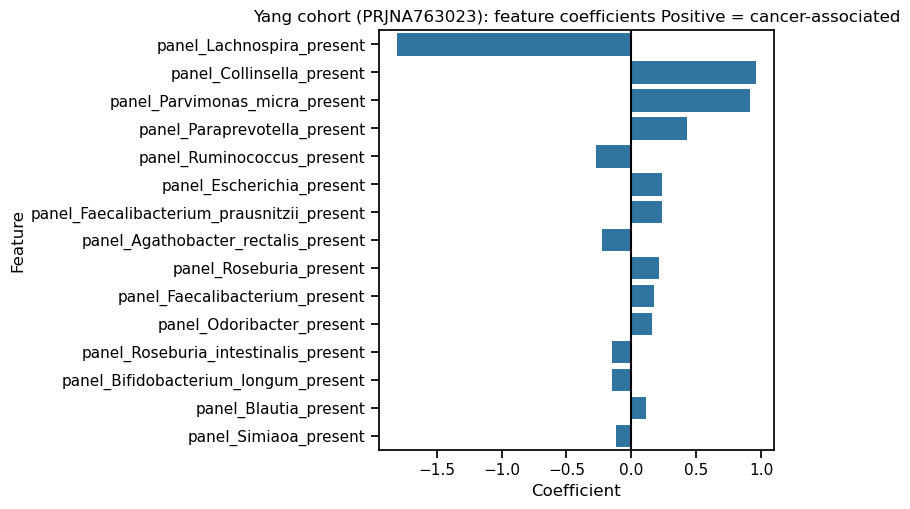

In [24]:
# Cell 23 — Descriptive feature importance for final model

# Note: this fits the final model on all samples and is descriptive, not cross-validated inference.

best_pipe.fit(X_best, y)

if isinstance(best_model, LogisticRegression):
    coefs = best_pipe.named_steps["model"].coef_[0]

    importance_df = pd.DataFrame({
        "feature": X_best.columns,
        "coefficient": coefs,
        "abs_coefficient": np.abs(coefs),
        "direction": np.where(coefs > 0, "cancer-associated", "healthy-associated"),
    }).sort_values("abs_coefficient", ascending=False)

    display(importance_df.head(20))

    plt.figure(figsize=(8, max(4, 0.35 * min(15, len(importance_df)))))
    sns.barplot(
        data=importance_df.head(15),
        x="coefficient",
        y="feature",
        orient="h",
    )
    plt.axvline(0, color="black")
    plt.title(f"{cohort_name}: feature coefficients Positive = cancer-associated")
    plt.xlabel("Coefficient")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

else:
    perm = permutation_importance(
        best_pipe,
        X_best,
        y,
        n_repeats=50,
        random_state=42,
        scoring="roc_auc",
    )

    importance_df = pd.DataFrame({
        "feature": X_best.columns,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std,
    }).sort_values("importance_mean", ascending=False)

    display(importance_df.head(20))

    plt.figure(figsize=(8, max(4, 0.35 * min(15, len(importance_df)))))
    sns.barplot(
        data=importance_df.head(15),
        x="importance_mean",
        y="feature",
        orient="h",
    )
    plt.title(f"{cohort_name}: permutation importance")
    plt.xlabel("Mean decrease in ROC AUC")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

,feature,importance_mean,importance_std
25,panel_Lachnospira_present,0.207325,0.062362
3,panel_Parvimonas_micra_present,0.093800,0.046674
31,panel_Collinsella_present,0.088125,0.047870
8,panel_Bifidobacterium_longum_present,0.018800,0.023886
34,panel_Odoribacter_present,0.014275,0.019577
29,panel_Paraprevotella_present,0.010575,0.020067
19,panel_Phascolarctobacterium_present,0.008950,0.015655
6,panel_Agathobacter_rectalis_present,0.006100,0.018668
21,panel_Ruminococcus_present,0.006100,0.018668
9,panel_Roseburia_intestinalis_present,0.004300,0.016495


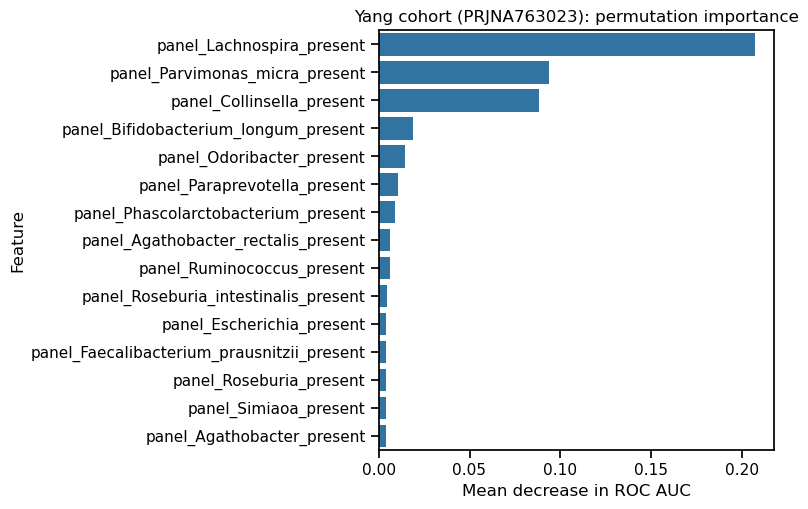

In [25]:
# Cell 24 — Permutation importance for best model, regardless of model type

# This gives a model-agnostic feature importance view.
# Note: descriptive; computed after fitting on all samples.

perm = permutation_importance(
    best_pipe,
    X_best,
    y,
    n_repeats=50,
    random_state=42,
    scoring="roc_auc",
)

perm_df = pd.DataFrame({
    "feature": X_best.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False)

display(perm_df.head(20))

plt.figure(figsize=(8, max(4, 0.35 * min(15, len(perm_df)))))
sns.barplot(
    data=perm_df.head(15),
    x="importance_mean",
    y="feature",
    orient="h",
)
plt.title(f"{cohort_name}: permutation importance")
plt.xlabel("Mean decrease in ROC AUC")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

,feature,feature_source,healthy_mean,cancer_mean,mean_diff,abs_diff,p_value,feature_type,importance_mean
0,panel_Lachnospira_present,presence,0.95,0.70,-0.25,0.25,0.041961,presence,0.207325
1,panel_Parvimonas_micra_present,presence,0.00,0.20,0.20,0.20,0.039817,presence,0.093800
2,panel_Collinsella_present,presence,0.60,0.75,0.15,0.15,0.325443,presence,0.088125
6,panel_Bifidobacterium_longum_present,presence,0.65,0.75,0.10,0.10,0.506466,presence,0.018800
18,panel_Odoribacter_present,presence,0.80,0.85,0.05,0.05,0.696281,presence,0.014275
3,panel_Paraprevotella_present,presence,0.90,1.00,0.10,0.10,0.162449,presence,0.010575
5,panel_Phascolarctobacterium_present,presence,0.85,0.75,-0.10,0.10,0.446592,presence,0.008950
23,panel_Ruminococcus_present,presence,0.95,0.95,0.00,0.00,1.000000,presence,0.006100
19,panel_Agathobacter_rectalis_present,presence,0.95,0.95,0.00,0.00,1.000000,presence,0.006100
20,panel_Roseburia_intestinalis_present,presence,0.95,0.95,0.00,0.00,1.000000,presence,0.004300


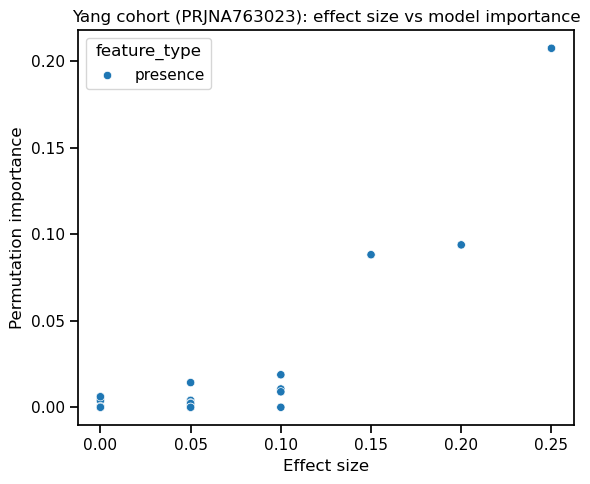

In [26]:
# Cell 25 — Combine effect size with permutation importance

# This helps distinguish features that differ between groups from features the model actually uses.

combined_effects = []
if not presence_effects.empty:
    tmp = presence_effects.copy()
    tmp["feature_type"] = "presence"
    combined_effects.append(tmp)
if not log_effects.empty:
    tmp = log_effects.copy()
    tmp["feature_type"] = "log10_abundance"
    combined_effects.append(tmp)

if combined_effects:
    effect_df = pd.concat(combined_effects, ignore_index=True)

    effect_importance_df = effect_df.merge(
        perm_df[["feature", "importance_mean"]],
        on="feature",
        how="inner",
    )

    display(effect_importance_df.sort_values("importance_mean", ascending=False).head(20))

    plt.figure(figsize=(6, 5))
    sns.scatterplot(
        data=effect_importance_df,
        x="abs_diff",
        y="importance_mean",
        hue="feature_type",
    )
    plt.xlabel("Effect size")
    plt.ylabel("Permutation importance")
    plt.title(f"{cohort_name}: effect size vs model importance")
    plt.tight_layout()
    plt.show()
else:
    print("No effect-size dataframe available to combine with permutation importance.")

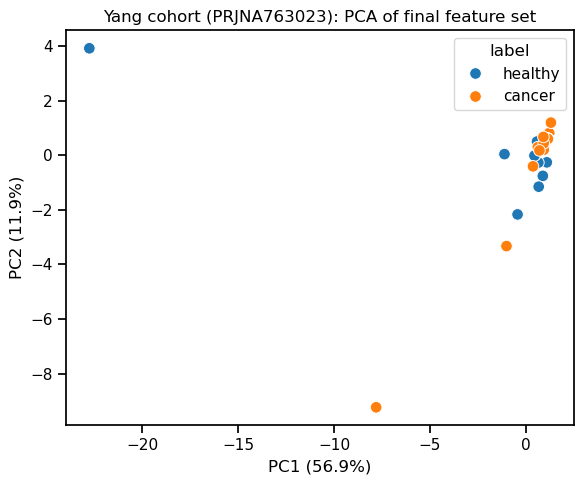

In [27]:
# Cell 26 — PCA visualization of selected feature set

X_plot = X_best.copy()

X_imp = SimpleImputer(strategy="constant", fill_value=0).fit_transform(X_plot)

if X_plot.shape[1] > 1:
    X_scaled = StandardScaler().fit_transform(X_imp)

    from sklearn.decomposition import PCA
    pca = PCA(n_components=2)
    pcs = pca.fit_transform(X_scaled)

    pca_df = pd.DataFrame({
        "PC1": pcs[:, 0],
        "PC2": pcs[:, 1],
        "label": df["label"].values,
        "sample_id": df["sample_id"].values,
    })

    plt.figure(figsize=(6, 5))
    sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="label", s=70)
    plt.title(f"{cohort_name}: PCA of final feature set")
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
    plt.tight_layout()
    plt.show()
else:
    print("PCA skipped: final feature set has fewer than 2 features.")

In [28]:
# Cell 27 — Save outputs

from pathlib import Path

out_dir = Path(out_dir)
out_dir.mkdir(parents=True, exist_ok=True)

# Save main results
results_df.to_csv(out_dir / f"{cohort_name}_model_comparison_results.csv", index=False)
cv_comparison_df.to_csv(out_dir / f"{cohort_name}_cv_comparison_results.csv", index=False)
cv_sensitivity_df.to_csv(out_dir / f"{cohort_name}_cv_sensitivity_results.csv", index=False)
perm_df.to_csv(out_dir / f"{cohort_name}_permutation_importance.csv", index=False)

# Save optional outputs if they exist
if "importance_df" in globals():
    importance_df.to_csv(out_dir / f"{cohort_name}_feature_importance.csv", index=False)

if "presence_effects" in globals() and not presence_effects.empty:
    presence_effects.to_csv(out_dir / f"{cohort_name}_presence_effect_sizes.csv", index=False)

if "log_effects" in globals() and not log_effects.empty:
    log_effects.to_csv(out_dir / f"{cohort_name}_log_effect_sizes.csv", index=False)

# Print a clean relative path instead of your full local machine path
try:
    display_path = out_dir.relative_to(Path.cwd())
except ValueError:
    display_path = out_dir.name

print(f"Saved results to: {display_path}")

Saved results to: Yang_PRJNA763023
